# Feature Extraction Showcase

This notebook demonstrates the end-to-end feature engineering pipeline for speech pathology classification.

It covers:
- running extraction via `FeatureOptions`
- inspecting the generated multi-table outputs
- basic quality checks and quick exploratory plots

In [4]:
import sys
from pathlib import Path

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..")

from src.features import FeatureOptions, load_feature_tables, summarize_feature_tables

In [5]:
# Configure extraction/loading behavior
opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=42,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    max_samples_per_class=50,  # Speed-up for testing; set None for full run.
 )

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=50, normalize_audio=True, target_sample_rate=None, mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [6]:
# Build missing tables if needed, otherwise load cached outputs
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)
summary = summarize_feature_tables(tables)
summary

Extracting features:  21%|██        | 65/314 [00:20<00:33,  7.53sample/s]g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\MFDFA\MFDFA.py:249: RuntimeWarning: divide by zero encountered in float_power
  np.mean(np.float_power(F, q / 2), axis=1),
Extracting features: 100%|██████████| 314/314 [02:06<00:00,  2.47sample/s]


{'num_samples': 314,
 'num_acoustic_rows': 314,
 'num_multifractal_rows': 314,
 'feature_status_counts': {'ok': 314},
 'acoustic_status_counts': {'ok': 314},
 'multifractal_status_counts': {'ok': 314},
 'split_counts': {'train': 219, 'test': 48, 'val': 47}}

## Inspect generated tables

The pipeline creates separate tables for metadata/core status, acoustic features, multifractal features, and splits.

In [7]:
for name, df in tables.items():
    print(f"{name}: shape={df.shape}")

core_df = tables["core"]
acoustic_df = tables["acoustic"]
multifractal_df = tables["multifractal"]
splits_df = tables.get("splits", pd.DataFrame())

core: shape=(314, 18)
acoustic: shape=(314, 87)
multifractal: shape=(314, 17)
splits: shape=(314, 3)


In [8]:
core_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,is_overlap_speaker,is_overlap_speaker_id,wav_path,feature_status,feature_error,audio_sample_rate,audio_num_samples,audio_duration_seconds
0,Morbus Parkinson::1580::vowels::a_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_h,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,None,50000,28864,0.57728
1,Morbus Parkinson::1580::vowels::a_l,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_l,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,None,50000,36123,0.72246
2,Morbus Parkinson::1580::vowels::a_lhl,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_lhl,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,None,50000,45391,0.90782
3,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,None,50000,36123,0.72246
4,Morbus Parkinson::1580::vowels::i_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,i_h,m,False,False,..\data\processed\wav\Morbus Parkinson\1580\vo...,ok,None,50000,38251,0.76502


In [9]:
acoustic_df.head()

,sample_key,acoustic_status,acoustic_error,ac_time_energy,ac_time_abs_mean,ac_time_peak,ac_time_crest_factor,ac_rms_mean,ac_rms_std,ac_rms_min,...,ac_mfcc12_delta_mean,ac_mfcc12_delta_std,ac_mfcc13_mean,ac_mfcc13_std,ac_mfcc13_delta_mean,ac_mfcc13_delta_std,ac_f0_mean,ac_f0_std,ac_f0_min,ac_f0_max
0,Morbus Parkinson::1580::vowels::a_h,ok,None,0.136878,0.311797,1.0,2.702923,0.361989,0.052316,0.234498,...,-0.083467,0.872922,-5.545632,4.178472,-0.156419,0.636762,179.013791,29.165446,94.379888,197.760774
1,Morbus Parkinson::1580::vowels::a_l,ok,None,0.110912,0.268923,1.0,3.002687,0.329604,0.023253,0.230419,...,0.030101,0.584257,-5.779543,4.559168,-0.134036,0.645118,160.845648,2.690300,152.663472,165.905134
2,Morbus Parkinson::1580::vowels::a_lhl,ok,None,0.104339,0.260001,1.0,3.095821,0.318222,0.045023,0.186317,...,-0.030593,1.023712,-9.565076,7.280129,-0.147624,0.698419,177.240006,13.103415,160.138585,204.448509
3,Morbus Parkinson::1580::vowels::a_n,ok,None,0.110912,0.268923,1.0,3.002687,0.329604,0.023253,0.230419,...,0.030101,0.584257,-5.779543,4.559168,-0.134036,0.645118,160.845648,2.690300,152.663472,165.905134
4,Morbus Parkinson::1580::vowels::i_h,ok,None,0.260261,0.447552,1.0,1.960178,0.504964,0.034980,0.401630,...,0.122696,1.029977,-26.474308,5.875587,-0.108147,0.974978,190.345780,4.673139,184.317933,205.185007


In [10]:
multifractal_df.head()

,sample_key,mf_status,mf_error,mf_hq_mean,mf_hq_std,mf_hq_min,mf_hq_max,mf_tau_mean,mf_tau_std,mf_alpha_mean,mf_alpha_std,mf_spectrum_width,mf_spectrum_peak_alpha,mf_spectrum_peak_f,mf_spectrum_asymmetry,mf_num_scales,mf_num_q
0,Morbus Parkinson::1580::vowels::a_h,ok,None,0.763622,0.194740,0.549508,1.080395,-1.629599,2.675148,0.835938,0.319092,0.792299,0.615091,0.977071,0.182400,20,10
1,Morbus Parkinson::1580::vowels::a_l,ok,None,0.754653,0.169290,0.559381,1.035577,-1.550596,2.617846,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10
2,Morbus Parkinson::1580::vowels::a_lhl,ok,None,0.734180,0.211263,0.493038,1.068850,-1.687689,2.574736,0.800038,0.343014,0.854544,0.572759,0.967594,0.208532,20,10
3,Morbus Parkinson::1580::vowels::a_n,ok,None,0.754653,0.169290,0.559381,1.035577,-1.550596,2.617846,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10
4,Morbus Parkinson::1580::vowels::i_h,ok,None,0.820211,0.130337,0.664646,1.035104,-1.426205,2.792983,0.862010,0.228141,0.596956,0.724345,0.974918,0.244982,20,10


## Join features for modeling

Join on `sample_key` to obtain one model-ready view while preserving separate storage tables.

In [11]:
model_df = core_df.merge(acoustic_df, on="sample_key", how="left")
model_df = model_df.merge(multifractal_df, on="sample_key", how="left")

if not splits_df.empty:
    model_df = model_df.merge(splits_df, on="sample_key", how="left")

model_df.head()

,sample_key,duplicate_class_key,recording_id,speaker_id,pathology_de,pathology_en,is_healthy,modality,token,sex,...,mf_alpha_mean,mf_alpha_std,mf_spectrum_width,mf_spectrum_peak_alpha,mf_spectrum_peak_f,mf_spectrum_asymmetry,mf_num_scales,mf_num_q,split,split_seed
0,Morbus Parkinson::1580::vowels::a_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_h,m,...,0.835938,0.319092,0.792299,0.615091,0.977071,0.182400,20,10,train,42
1,Morbus Parkinson::1580::vowels::a_l,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_l,m,...,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10,val,42
2,Morbus Parkinson::1580::vowels::a_lhl,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_lhl,m,...,0.800038,0.343014,0.854544,0.572759,0.967594,0.208532,20,10,train,42
3,Morbus Parkinson::1580::vowels::a_n,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,a_n,m,...,0.814805,0.292166,0.752851,0.629105,0.973514,0.224294,20,10,train,42
4,Morbus Parkinson::1580::vowels::i_h,Morbus Parkinson::1580,1580,1887,Morbus Parkinson,parkinson's disease,False,vowels,i_h,m,...,0.862010,0.228141,0.596956,0.724345,0.974918,0.244982,20,10,train,42


In [12]:
# Basic quality checks
status_cols = [c for c in ["feature_status", "acoustic_status", "mf_status"] if c in model_df.columns]
for col in status_cols:
    print(f"\n{col}\n", model_df[col].value_counts(dropna=False))

print("\nMissingness (top 20 columns):")
display(model_df.isna().mean().sort_values(ascending=False).head(20))


feature_status
 feature_status
ok    314
Name: count, dtype: int64

acoustic_status
 acoustic_status
ok    314
Name: count, dtype: int64

mf_status
 mf_status
ok    314
Name: count, dtype: int64

Missingness (top 20 columns):


acoustic_error            1.0
feature_error             1.0
mf_error                  1.0
recording_id              0.0
pathology_de              0.0
speaker_id                0.0
is_healthy                0.0
modality                  0.0
sample_key                0.0
pathology_en              0.0
sex                       0.0
token                     0.0
wav_path                  0.0
is_overlap_speaker        0.0
feature_status            0.0
audio_sample_rate         0.0
audio_num_samples         0.0
is_overlap_speaker_id     0.0
audio_duration_seconds    0.0
acoustic_status           0.0
dtype: float64

## Quick exploratory plots

These are lightweight sanity checks to visualize class balance and a few extracted features.

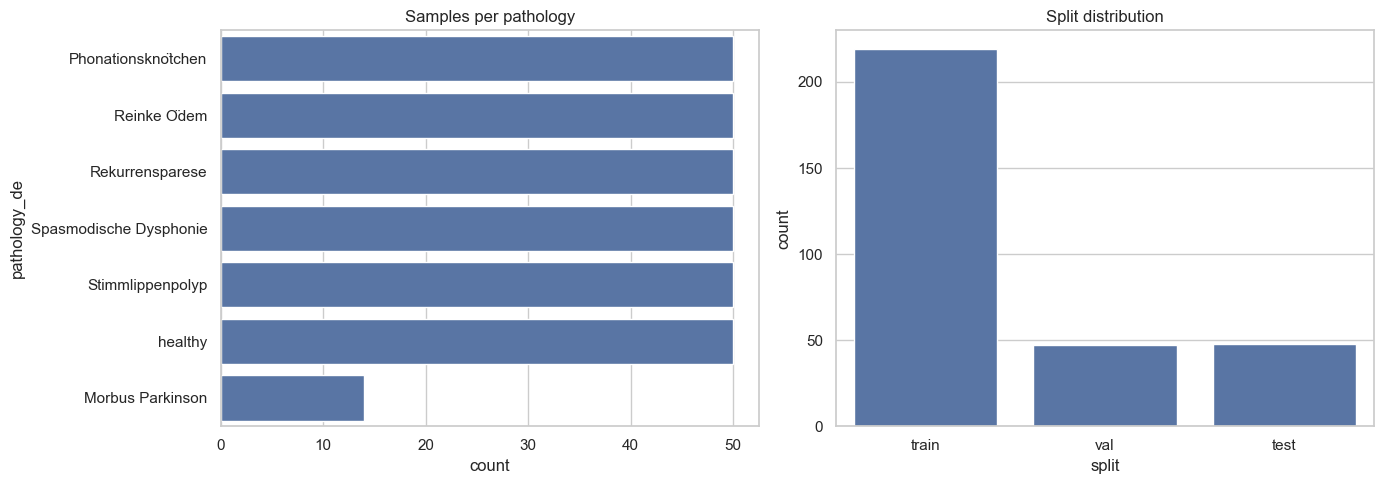

In [13]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if "pathology_de" in model_df.columns:
    order = model_df["pathology_de"].value_counts().index
    sns.countplot(data=model_df, y="pathology_de", order=order, ax=ax[0])
    ax[0].set_title("Samples per pathology")

if "split" in model_df.columns:
    sns.countplot(data=model_df, x="split", order=["train", "val", "test"], ax=ax[1])
    ax[1].set_title("Split distribution")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()

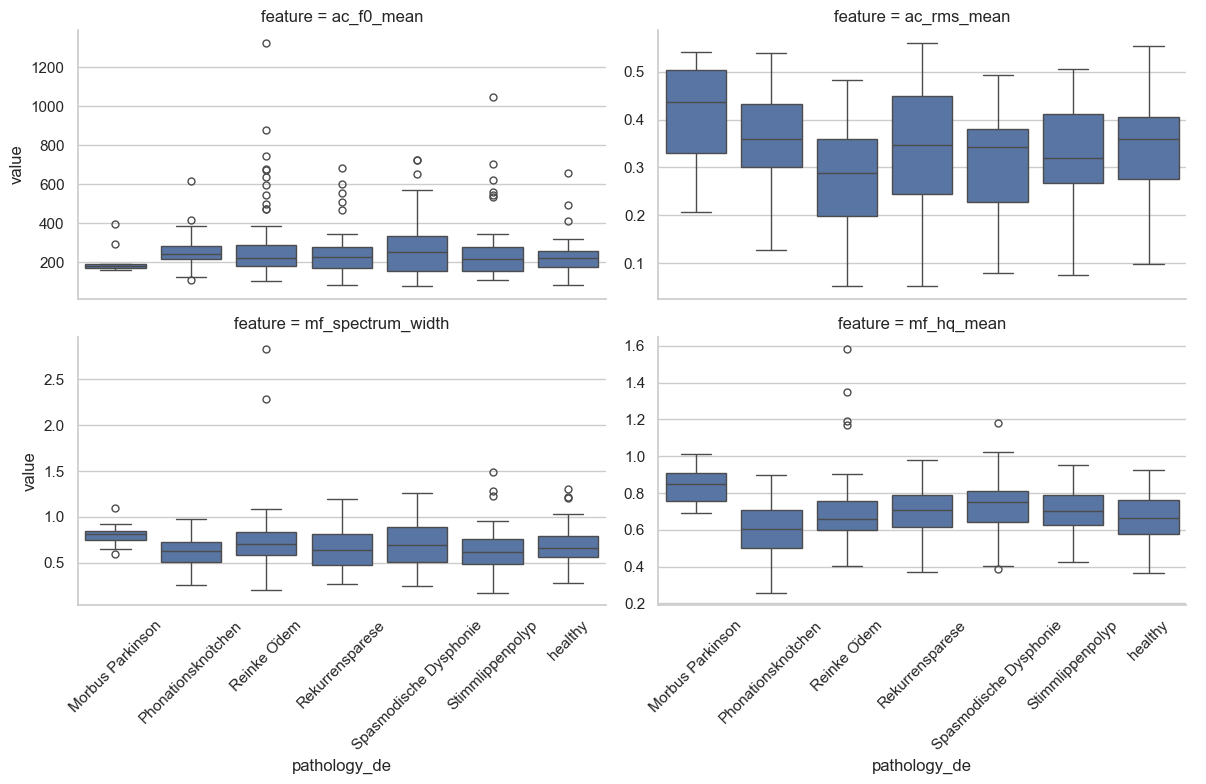

In [14]:
candidate_features = ["ac_f0_mean", "ac_rms_mean", "mf_spectrum_width", "mf_hq_mean"]
existing = [c for c in candidate_features if c in model_df.columns]

if existing and "pathology_de" in model_df.columns:
    plot_df = model_df[["pathology_de", *existing]].copy()
    melted = plot_df.melt(id_vars="pathology_de", var_name="feature", value_name="value")

    g = sns.catplot(
        data=melted,
        x="pathology_de",
        y="value",
        col="feature",
        col_wrap=2,
        kind="box",
        sharey=False,
        height=4,
        aspect=1.5,
    )
    for axis in g.axes.flatten():
        axis.tick_params(axis="x", rotation=45)
    g.fig.tight_layout()
    plt.show()
else:
    print("No candidate columns found yet for feature-by-pathology plot.")

## Persist a model-ready snapshot (optional)

Use this cell if you want a single joined table for rapid prototyping.

In [15]:
out_path = Path("..") / "data" / "processed" / "features" / "model_table_snapshot.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
model_df.to_csv(out_path, index=False)
print(f"Wrote: {out_path.resolve()}")

Wrote: G:\Projects\multifractal-speech-analysis\data\processed\features\model_table_snapshot.csv
